In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset original en crudo: la versión completa de `listings`, con 90 columnas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/raw/sevilla/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1309470637323585850,https://www.airbnb.com/rooms/1309470637323585850,20260630144934,2026-07-01,city scrape,Hispalis Conde de Ibarra,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,105842350,...,NaN,NaN,NaN,Andalucia - Regional registration number<br />...,NaN,49,49,0,0,NaN
1,1096284527529773882,https://www.airbnb.com/rooms/1096284527529773882,20260630144934,2026-07-03,previous scrape,Disfrutad de una Gran ciudad,Break with your day-to-day life and relax for ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,76877691,...,5.00,4.43,4.43,NaN,NaN,2,0,2,0,0.25
2,1097019839996380347,https://www.airbnb.com/rooms/1097019839996380347,20260630144934,2026-07-03,previous scrape,FERIA 1.800 € semana 2-4 plazas Los Remedios,Enjoy the simplicity of this centrally located...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,82634140,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,1160634917963642559,https://www.airbnb.com/rooms/1160634917963642559,20260630144934,2026-07-03,previous scrape,Cristo de Burgos 21,Enjoy a stylish experience at this centrally-l...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,209748933,...,4.18,5.00,4.82,Andalucia - Regional registration number<br />...,NaN,52,52,0,0,0.43
4,1176267309003810875,https://www.airbnb.com/rooms/1176267309003810875,20260630144934,2026-07-03,previous scrape,Virgen de Luján Los Remedios,Beautiful apartment located in the best neighb...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,550866109,...,NaN,NaN,NaN,Andalucia - Regional registration number<br />...,NaN,1,1,0,0,NaN


## 2. Básico

Primer vistazo a la estructura del dataset: dimensiones, tipos de datos y estadísticos descriptivos generales.

In [3]:
print(df.shape)
df.dtypes.value_counts()

(8245, 90)


float64    36
object     30
int64      24
Name: count, dtype: int64

90 columnas (8245 filas): 36 `float64`, 30 `object`, 24 `int64` — el mismo reparto de tipos que en Barcelona/Madrid/Valencia/Málaga, señal de que las cinco ciudades vienen del mismo export de Inside Airbnb. Igual que en las otras cuatro, `price` es `object` en vez de numérico (se corrige en la sección 3), y hay columnas `float64` que por su nombre deberían ser texto o fecha (`host_since`, `host_response_time`...), lo que hace sospechar que están vacías.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].sort_index()

calendar_updated             100.0
host_acceptance_rate         100.0
host_neighbourhood           100.0
host_response_rate           100.0
host_response_time           100.0
host_since                   100.0
host_thumbnail_url           100.0
host_total_listings_count    100.0
host_verifications           100.0
instant_bookable             100.0
neighborhood_overview        100.0
neighbourhood                100.0
dtype: float64

**Las mismas 12 columnas que en las otras cuatro ciudades están completamente vacías** (100% nulas): `neighbourhood`, `host_acceptance_rate`, `host_response_time`, `host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `host_since`, `host_response_rate`, `instant_bookable`, `neighborhood_overview`, `calendar_updated`. De las 90 columnas, solo 78 tienen algún dato real. No se eliminan aquí, se tratan formalmente en la sección 4 (Nulos).

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,8245.0,6.860849e+17,6.314256e+17,4.928700e+04,3.582392e+07,7.615896e+17,1.286385e+18,1.716817e+18
scrape_id,8245.0,2.026063e+13,0.000000e+00,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,8245.0,4.929263e+15,9.124018e+16,1.630020e+05,3.846239e+07,1.596985e+08,4.108371e+08,1.715804e+18
host_profile_id,8245.0,1.471678e+18,2.836655e+16,1.462510e+18,1.462925e+18,1.467002e+18,1.469754e+18,1.715804e+18
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,8245.0,7.675804e+00,3.829525e+00,0.000000e+00,4.000000e+00,8.000000e+00,1.000000e+01,1.500000e+01
hosts_time_as_user_months,8245.0,5.150030e+00,3.393586e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
hosts_time_as_host_years,8245.0,6.815525e+00,3.866815e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01,1.500000e+01
hosts_time_as_host_months,8245.0,4.879806e+00,3.280215e+00,0.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00,1.100000e+01


Igual que en las otras cuatro ciudades: `price` llega como texto (`"$139.50"`, no `139.50`), y aparece la misma familia `price_quote_*` (una cotización para unas fechas concretas de check-in/check-out, no el precio base del anuncio). Se tratan en la sección 3 y se retoman al analizar `price` a fondo en las secciones 7-8.

## 3. Corrección de tipos

Ajustar columnas con un tipo de dato mal inferido. Mismos pasos que en las otras cuatro ciudades, aplicados aquí a Sevilla.

#### `price`

Llega como texto con símbolo de moneda y separador de miles. Se limpia y se convierte a `float`.

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].dtype

dtype('float64')

#### Fechas

`last_scraped`, `first_review`, `last_review` y `calendar_last_scraped` son fechas guardadas como texto. `host_since` se deja fuera: es una de las 12 columnas 100% vacías (se eliminará en la sección 4).

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df[date_cols].dtypes

last_scraped             datetime64[ns]
first_review             datetime64[ns]
last_review              datetime64[ns]
calendar_last_scraped    datetime64[ns]
dtype: object

#### Flags `t`/`f`

`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` y `has_availability` son booleanos codificados como texto (`"t"`/`"f"`), con algún nulo suelto. Se mapean a `boolean` (tipo nullable de pandas).

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}).astype("boolean"))
df[bool_cols].dtypes

host_is_superhost         boolean
host_has_profile_pic      boolean
host_identity_verified    boolean
has_availability          boolean
dtype: object

#### `host_profile_id`

Identificador entero con algunos nulos, pandas lo infirió como `float64`. Se pasa a `Int64` (entero nullable).

In [9]:
df["host_profile_id"] = df["host_profile_id"].astype("Int64")
df["host_profile_id"].dtype

Int64Dtype()

#### Distritos y barrios: sin normalizar, a diferencia de Valencia

`neighbourhood_cleansed` (102 valores) y `neighbourhood_group_cleansed` (11 valores) llegan ya en formato legible (`"Casco Antiguo"`, `"San Bartolomé"`...), sin mayúsculas sueltas ni espacios sobrantes. A diferencia de Valencia (que traía `"CIUTAT VELLA"` en mayúsculas sin tildes), el export de Sevilla se comporta como el de Barcelona/Madrid: no hace falta ningún `title_case_place()`.

In [10]:
df[["neighbourhood_cleansed", "neighbourhood_group_cleansed"]].drop_duplicates().head(8)

,neighbourhood_cleansed,neighbourhood_group_cleansed
0,San Bartolomé,Casco Antiguo
1,Rochelambert,Cerro - Amate
2,Los Remedios,Los Remedios
3,Alfalfa,Casco Antiguo
5,Santa Cruz,Casco Antiguo
6,Feria,Casco Antiguo
7,San Lorenzo,Casco Antiguo
8,Museo,Casco Antiguo


Quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` y el resto de `price_quote_*`: su utilidad real se decide al analizar `price` a fondo, no aquí.

## 4. Nulos

Identificar qué columnas tienen valores nulos, en qué proporción, y decidir cómo tratarlos.

In [11]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_total_listings_count      100.00
instant_bookable               100.00
host_response_time             100.00
host_response_rate             100.00
host_since                     100.00
host_acceptance_rate           100.00
host_thumbnail_url             100.00
host_neighbourhood             100.00
calendar_updated               100.00
neighborhood_overview          100.00
host_verifications             100.00
neighbourhood                  100.00
host_about                      43.47
host_location                   24.94
bathrooms                       14.29
bedrooms                        12.08
beds                            10.62
first_review                     7.64
reviews_per_month                7.64
last_review                      7.64
review_scores_communication      7.64
review_scores_rating             7.64
review_scores_location           7.64
review_scores_value              7.64
review_scores_checkin            7.64
review_scores_cleanliness        7.64
review_score

### 4.1 Estrategia

Mismo criterio que en las otras cuatro ciudades, cada grupo de columnas según su causa:
- 12 columnas 100% vacías → se eliminan.
- `bathrooms` → se recupera desde `bathrooms_text`.
- Reviews (`reviews_per_month`, `first_review`/`last_review`, `review_scores_*`) → sin reviews todavía.
- `license` → sin licencia registrada.
- `price` → variable clave, no se imputa.
- Columnas de bajo volumen (host, disponibilidad, estancia) → se descartan las filas.
- `bedrooms`/`beds` → mediana por `room_type`.
- Campos de texto libre (`host_about`, `host_location`, `description`) → se dejan tal cual.

#### Columnas 100% vacías

In [12]:
empty_cols = [
    "neighbourhood", "host_acceptance_rate", "host_response_time", "host_thumbnail_url",
    "host_neighbourhood", "host_total_listings_count", "host_verifications", "host_since",
    "host_response_rate", "instant_bookable", "neighborhood_overview", "calendar_updated",
]
df = df.drop(columns=empty_cols)
df.shape

(8245, 78)

#### `bathrooms`

`bathrooms` (numérico) tiene 1178 nulos, pero `bathrooms_text` (texto, p. ej. `"1.5 baths"`) solo tiene 3. Se extrae el número de `bathrooms_text` (con `"half-bath"` → 0.5) y se usa para rellenar `bathrooms`.

In [13]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
half_mask = df["bathrooms_text"].str.contains("half-bath", case=False, na=False) & bathrooms_extracted.isnull()
bathrooms_extracted[half_mask] = 0.5

recovered = df["bathrooms"].isnull() & bathrooms_extracted.notnull()
print("bathrooms recuperados desde bathrooms_text:", recovered.sum())

df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
df["bathrooms"].isnull().sum()

bathrooms recuperados desde bathrooms_text: 1178


np.int64(0)

Los 1178 nulos se recuperan por completo (27 de ellos venían de `bathrooms_text` en formato `"Half-bath"`/`"Shared half-bath"`, sin ningún dígito que extraer con la regex — se cubren con la máscara de 0.5 antes de la extracción numérica, el mismo caso ya visto en Málaga pero con más filas afectadas aquí).

#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_*`)

Se comprueba que el nulo coincide con `number_of_reviews == 0`.

In [14]:
mask = df["review_scores_rating"].isnull()
print("coincide con number_of_reviews == 0:", (df.loc[mask, "number_of_reviews"] == 0).all())
print("reviews_per_month coincide:", (df["reviews_per_month"].isnull() == mask).all())

coincide con number_of_reviews == 0: True
reviews_per_month coincide: True


Se confirma. `reviews_per_month` se imputa a 0. `first_review`/`last_review` se dejan como `NaT`, y `review_scores_*` como `NaN`: sin reviews no hay puntuación real que inventar.

In [15]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

El nulo probablemente significa que no hay licencia registrada. Se guarda como flag antes de imputar el texto.

In [16]:
df["has_license"] = df["license"].notna()
print(df["has_license"].value_counts(normalize=True).mul(100).round(2))
df["license"] = df["license"].fillna("Sin licencia")

has_license
True     93.71
False     6.29
Name: proportion, dtype: float64


93.71% de los anuncios tiene licencia registrada, un porcentaje alto y en línea con Málaga (93.1%), muy por encima de Valencia (80.9%).

#### `price`

Variable clave (7.29% nulo, 601 filas): no se imputa, se descartan esas filas.

In [17]:
df = df.dropna(subset=["price"])
df.shape

(7644, 79)

#### Columnas de bajo volumen (host, disponibilidad, estancia)

Afectan a muy pocas filas (0.05% del dataset), se descartan las filas en vez de imputar identificadores/metadatos de cuenta.

In [18]:
low_vol_cols = [
    "host_profile_id", "host_is_superhost", "host_name", "hosts_time_as_user_years",
    "host_identity_verified", "host_has_profile_pic", "hosts_time_as_user_months",
    "hosts_time_as_host_years", "host_listings_count", "hosts_time_as_host_months",
    "host_picture_url", "host_profile_url", "has_availability", "bathrooms_text",
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
]
df = df.dropna(subset=low_vol_cols)
df.shape

(7640, 79)

#### `bedrooms` / `beds`

Tras lo anterior quedan `bedrooms` con 11.75% de nulos y `beds` con 4.69%. Igual que en las otras ciudades, el nulo de `bedrooms` no es aleatorio: se concentra en `Private room` (58.4%) y `Shared room` (25.0%) frente a `Entire home/apt` (5.2%) y `Hotel room` (0%).

In [19]:
print(df.groupby("room_type")["bedrooms"].apply(lambda s: s.isnull().mean() * 100).round(1))
print()
print(df.groupby("room_type")["bedrooms"].median())

room_type
Entire home/apt     5.2
Hotel room          0.0
Private room       58.4
Shared room        25.0
Name: bedrooms, dtype: float64

room_type
Entire home/apt    1.0
Hotel room         1.0
Private room       1.0
Shared room        1.0
Name: bedrooms, dtype: float64


Se imputa con la **mediana de `bedrooms`/`beds` dentro de cada `room_type`**, la misma regla que en las otras cuatro ciudades. Una diferencia real con Barcelona/Madrid/Valencia/Málaga: aquí la mediana de `bedrooms` para `Entire home/apt` es **1**, no 2 — el parque de pisos completos en Sevilla se inclina hacia estudios/1 dormitorio con más fuerza que en las otras ciudades.

In [20]:
df["bedrooms"] = df.groupby("room_type")["bedrooms"].transform(lambda s: s.fillna(s.median()))
df["beds"] = df.groupby("room_type")["beds"].transform(lambda s: s.fillna(s.median()))

df[["bedrooms", "beds"]].isnull().sum()

bedrooms    0
beds        0
dtype: int64

In [21]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_about                     43.08
host_location                  25.35
review_scores_cleanliness       6.69
first_review                    6.69
last_review                     6.69
review_scores_rating            6.69
review_scores_accuracy          6.69
review_scores_value             6.69
review_scores_location          6.69
review_scores_communication     6.69
review_scores_checkin           6.69
description                     3.08
price_quote_total_price         0.01
price_quote_price_per_night     0.01
dtype: float64

Quedan sin tratar, a propósito: `review_scores_*`/`first_review`/`last_review` (informativamente vacíos) y los campos de texto libre `host_about`, `host_location`, `description`.

## 5. Duplicados

Comprobar si existen filas duplicadas en el dataset y eliminarlas si procede.

In [22]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que la fila completa.

In [23]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

Filas que comparten `name`, `host_name`, `latitude` y `longitude` pero tienen `id` distinto.

In [24]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
logical_dup_mask = df.duplicated(subset=dup_cols, keep=False)

print("filas implicadas:", logical_dup_mask.sum())
print("grupos:", df[logical_dup_mask].groupby(dup_cols).ngroups)

filas implicadas: 85
grupos: 22


85 filas repartidas en 22 grupos: igual que en las otras ciudades, en su mayoría son aparthoteles que publican la misma unidad tipo varias veces (p. ej. "Elegance and luxury in the centre of Sevilla" de "Gravina 31 Apartamentos", con 13 anuncios casi idénticos salvo `id`). Se comprueba si alguno coincide también en el resto de columnas.

In [25]:
cols_except_id = [c for c in df.columns if c != "id"]
is_real_duplicate = df.duplicated(subset=cols_except_id, keep="first")
is_real_duplicate.sum()

np.int64(0)

#### Conclusión

0 filas duplicadas de fila completa, 0 `id` repetidos, y 0 filas idénticas en todo salvo `id`: **no hay ningún duplicado que eliminar**. Los 85 "duplicados lógicos" son anuncios reales distintos (unidades diferentes del mismo edificio/aparthotel), con datos propios en el resto de columnas. No se toca nada.

## 6. Variables Categóricas

Análisis univariante de las variables categóricas: cardinalidad y distribución de frecuencias.

In [26]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

listing_url                     7640
picture_url                     7611
name                            7491
amenities                       7165
price_quote_raw                 6675
description                     6454
license                         5604
host_profile_url                2752
host_url                        2752
host_picture_url                2708
host_about                      1231
host_name                       1158
price_quote_checkout_date        187
price_quote_checkin_date         171
host_location                    136
neighbourhood_cleansed           102
property_type                     42
bathrooms_text                    31
neighbourhood_group_cleansed      11
room_type                          4
has_availability                   2
host_identity_verified             2
source                             2
host_has_profile_pic               2
host_is_superhost                  2
has_license                        2
dtype: int64

### 6.1 Cardinalidad: los mismos cuatro grupos que en las otras ciudades

- **URLs**, cardinalidad prácticamente igual al nº de filas (`listing_url`, `picture_url`, `host_url`...): sin valor analítico.
- **Cuasi-identificadores de texto libre** (`name`, `description`, `host_about`, `amenities`, `host_name`, `host_location`, `license`): se difiere a feature engineering.
- **Pendientes de la sección 7-8** (`price_quote_checkin_date`, `price_quote_checkout_date`, `price_quote_raw`).
- **`bathrooms_text`**: ya cumplió su función en la sección 4.
- **Categóricas reales de baja cardinalidad**: `source` (2), `property_type` (42), `room_type` (4), `neighbourhood_cleansed` (102), `neighbourhood_group_cleansed` (11), `has_availability` (2), y los booleanos `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `has_license`.

Sevilla tiene **11 distritos** y **102 barrios**: la misma jerarquía distrito/barrio de Barcelona/Madrid/Valencia (a diferencia de Málaga, que no la trae).

### 6.2 Categóricas de baja cardinalidad

#### `has_availability`

In [27]:
df["has_availability"].value_counts(dropna=False)

has_availability
True     7638
False       2
Name: count, dtype: Int64

7638 `True` frente a solo 2 `False`: prácticamente constante (99.97%). Con tan poca variación no va a distinguir nada como predictora, así que se elimina igual que en las otras ciudades.

In [28]:
df = df.drop(columns=["has_availability"])

#### `source`

In [29]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        97.0
previous scrape     3.0
Name: proportion, dtype: float64

97.0% `city scrape` / 3.0% `previous scrape`, en línea con las otras cuatro ciudades. Metadato de recolección, se descarta como feature.

#### `property_type`

In [30]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   5671
Private room in rental unit           389
Entire condo                          241
Entire home                           237
Private room in home                  223
Entire loft                           204
Entire serviced apartment             181
Private room in hostel                102
Room in hotel                          88
Room in aparthotel                     35
Entire vacation home                   30
Private room in bed and breakfast      30
Private room in condo                  24
Private room in townhouse              22
Entire townhouse                       21
Name: count, dtype: int64

Dominado por `Entire rental unit` (74.2%), un nivel de concentración parecido a Málaga (73.4%) y muy por encima de Valencia (64.7%). Con 42 categorías y una cola larga de una sola aparición cada una, se agrupará por frecuencia en feature engineering.

#### `room_type`

In [31]:
df["room_type"].value_counts()

room_type
Entire home/apt    6665
Private room        937
Shared room          24
Hotel room           14
Name: count, dtype: int64

`Entire home/apt` domina con fuerza (87.2%), `Private room` es la única categoría secundaria con peso real (12.3%); `Shared room` y `Hotel room` son casi residuales (24 y 14 filas).

#### `neighbourhood_group_cleansed` / `neighbourhood_cleansed`

In [32]:
df["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Casco Antiguo                  5325
Triana                          873
Nervión                         448
Macarena                        245
San Pablo - Santa Justa         163
Los Remedios                    158
Sur                             124
Palmera - Bellavista             94
Cerro - Amate                    88
Este - Alcosa - Torreblanca      68
Macarena - Norte                 54
Name: count, dtype: int64

`Casco Antiguo` concentra **el 69.7%** de todo el dataset, una concentración geográfica extrema — más fuerte que en Barcelona/Madrid/Valencia (donde el distrito más grande ronda el 15-20%) y comparable a la de `Centro` en Málaga (67.5%), aunque aquí sí hay un nivel de distrito real por encima de los 102 barrios. El resto se reparte entre 10 distritos con muestras mucho más pequeñas, varios de ellos (`Macarena - Norte`, `Este - Alcosa - Torreblanca`) con menos de 70 anuncios.

#### Columnas booleanas

In [33]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c)
    print(df[c].value_counts(normalize=True).mul(100).round(1))
    print()

host_is_superhost
host_is_superhost
False    59.6
True     40.4
Name: proportion, dtype: Float64

host_has_profile_pic
host_has_profile_pic
True     98.5
False     1.5
Name: proportion, dtype: Float64

host_identity_verified
host_identity_verified
True     99.4
False     0.6
Name: proportion, dtype: Float64

has_license
has_license
True     94.4
False     5.6
Name: proportion, dtype: float64



`host_has_profile_pic` (98.5%) y `host_identity_verified` (99.4%) casi siempre a `True`, poca variabilidad. `host_is_superhost` (40.4%) es el más alto de las cinco ciudades. `has_license` (94.4%) confirma lo visto en la sección 4.

## 7. Numéricas

Análisis univariante de las variables numéricas: estadísticos descriptivos y forma de la distribución.

In [34]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols.tolist())
len(num_cols)

['id', 'scrape_id', 'host_id', 'host_profile_id', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_h

49

### 7.1 Identificadores/geográficas vs. variables de interés

49 columnas numéricas, igual que en las otras cuatro ciudades (mismo esquema de columnas). `id`, `scrape_id`, `host_id`, `host_profile_id` son identificadores; `latitude`/`longitude` se tratan en la sección 11. El resto tiene las mismas familias redundantes ya vistas en las otras ciudades, se revisan antes de elegir cuáles analizar a fondo.

### 7.2 Familias de variables redundantes

In [35]:
nights_family = [
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
]
df[nights_family].corr().round(2)

,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm
minimum_nights,1.00,-0.04,1.00,0.38,-0.01,-0.04,0.84,-0.03
maximum_nights,-0.04,1.00,-0.04,0.03,0.83,1.00,-0.01,0.93
minimum_minimum_nights,1.00,-0.04,1.00,0.38,-0.01,-0.04,0.84,-0.03
maximum_minimum_nights,0.38,0.03,0.38,1.00,0.03,0.03,0.56,0.02
minimum_maximum_nights,-0.01,0.83,-0.01,0.03,1.00,0.83,0.01,0.95
maximum_maximum_nights,-0.04,1.00,-0.04,0.03,0.83,1.00,-0.01,0.93
minimum_nights_avg_ntm,0.84,-0.01,0.84,0.56,0.01,-0.01,1.00,0.00
maximum_nights_avg_ntm,-0.03,0.93,-0.03,0.02,0.95,0.93,0.00,1.00


`minimum_nights` y `minimum_minimum_nights` correlacionan **1.00**, literalmente el mismo dato, igual que en las otras ciudades. Se sigue usando solo `minimum_nights`/`maximum_nights`.

In [36]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365", "availability_eoy"]
df[avail_family].corr().round(2)

,availability_30,availability_60,availability_90,availability_365,availability_eoy
availability_30,1.00,0.89,0.80,0.23,0.47
availability_60,0.89,1.00,0.93,0.31,0.58
availability_90,0.80,0.93,1.00,0.42,0.73
availability_365,0.23,0.31,0.42,1.00,0.76
availability_eoy,0.47,0.58,0.73,0.76,1.00


Solape moderado (0.23 a 0.89). Se sigue usando `availability_365`, la más completa.

### 7.3 Comprobación: `hosts_time_as_*` y `host_listings_count`

In [37]:
hosts_time_cols = ["hosts_time_as_user_years", "hosts_time_as_user_months", "hosts_time_as_host_years", "hosts_time_as_host_months"]
df[hosts_time_cols].describe()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months
count,7640.000000,7640.000000,7640.000000,7640.000000
mean,7.702749,5.132853,6.874215,4.871073
std,3.830243,3.375294,3.871515,3.268137
min,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.000000,4.000000,2.000000
50%,8.000000,5.000000,7.000000,4.000000
75%,10.000000,8.000000,10.000000,8.000000
max,15.000000,11.000000,15.000000,11.000000


Sin nulos, rangos razonables: son campos derivados que sobrevivieron aunque `host_since` esté vacía, igual que en las otras ciudades.

In [38]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.560424
calculated_host_listings_count,0.560424,1.000000


Correlación moderada (0.56), la misma magnitud vista en Málaga: `host_listings_count` (autodeclarado) y `calculated_host_listings_count` (recalculado dentro del dataset) miden cosas relacionadas pero no idénticas. Se mantiene `calculated_host_listings_count`, más fiable por construcción.

### 7.4 Variables clave: estadísticos y asimetría

In [39]:
num_vars = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "calculated_host_listings_count", "estimated_revenue_l365d",
]
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
price,7640.0,149.820925,303.598584,4.78,80.00,107.10,146.50,10970.00
accommodates,7640.0,3.901571,1.881208,1.00,2.00,4.00,4.00,16.00
bathrooms,7640.0,1.318259,0.673581,0.00,1.00,1.00,1.50,9.00
bedrooms,7640.0,1.598822,0.883396,1.00,1.00,1.00,2.00,13.00
beds,7640.0,2.488874,1.609512,1.00,1.00,2.00,3.00,28.00
minimum_nights,7640.0,2.671204,7.884326,1.00,1.00,1.00,2.00,100.00
maximum_nights,7640.0,663.408246,438.128847,1.00,365.00,730.00,1125.00,1125.00
availability_365,7640.0,197.775262,100.921341,0.00,111.00,193.00,288.00,365.00
number_of_reviews,7640.0,95.657592,136.080857,0.00,8.00,42.00,128.00,1435.00
number_of_reviews_ltm,7640.0,19.155105,21.641049,0.00,2.00,11.00,30.00,368.00


In [40]:
df[num_vars].skew().sort_values(ascending=False)

price                             18.186737
estimated_revenue_l365d           12.713404
minimum_nights                     7.341632
calculated_host_listings_count     3.105609
bathrooms                          3.011272
number_of_reviews                  2.691383
beds                               2.569508
bedrooms                           2.263490
number_of_reviews_ltm              1.972024
reviews_per_month                  1.899007
accommodates                       1.706345
availability_365                  -0.026307
maximum_nights                    -0.159980
review_scores_rating              -4.677564
dtype: float64

`price` tiene una asimetría alta (**18.2**), del mismo orden que Valencia (20.1) y muy por debajo de Málaga (88.4). `estimated_revenue_l365d` (12.7) y `minimum_nights` (7.3) también destacan. `review_scores_rating` repite la asimetría negativa fuerte (-4.68) ya vista en las otras ciudades: la mayoría puntúa muy alto. Se investiga la cola de `price` en la sección 8.

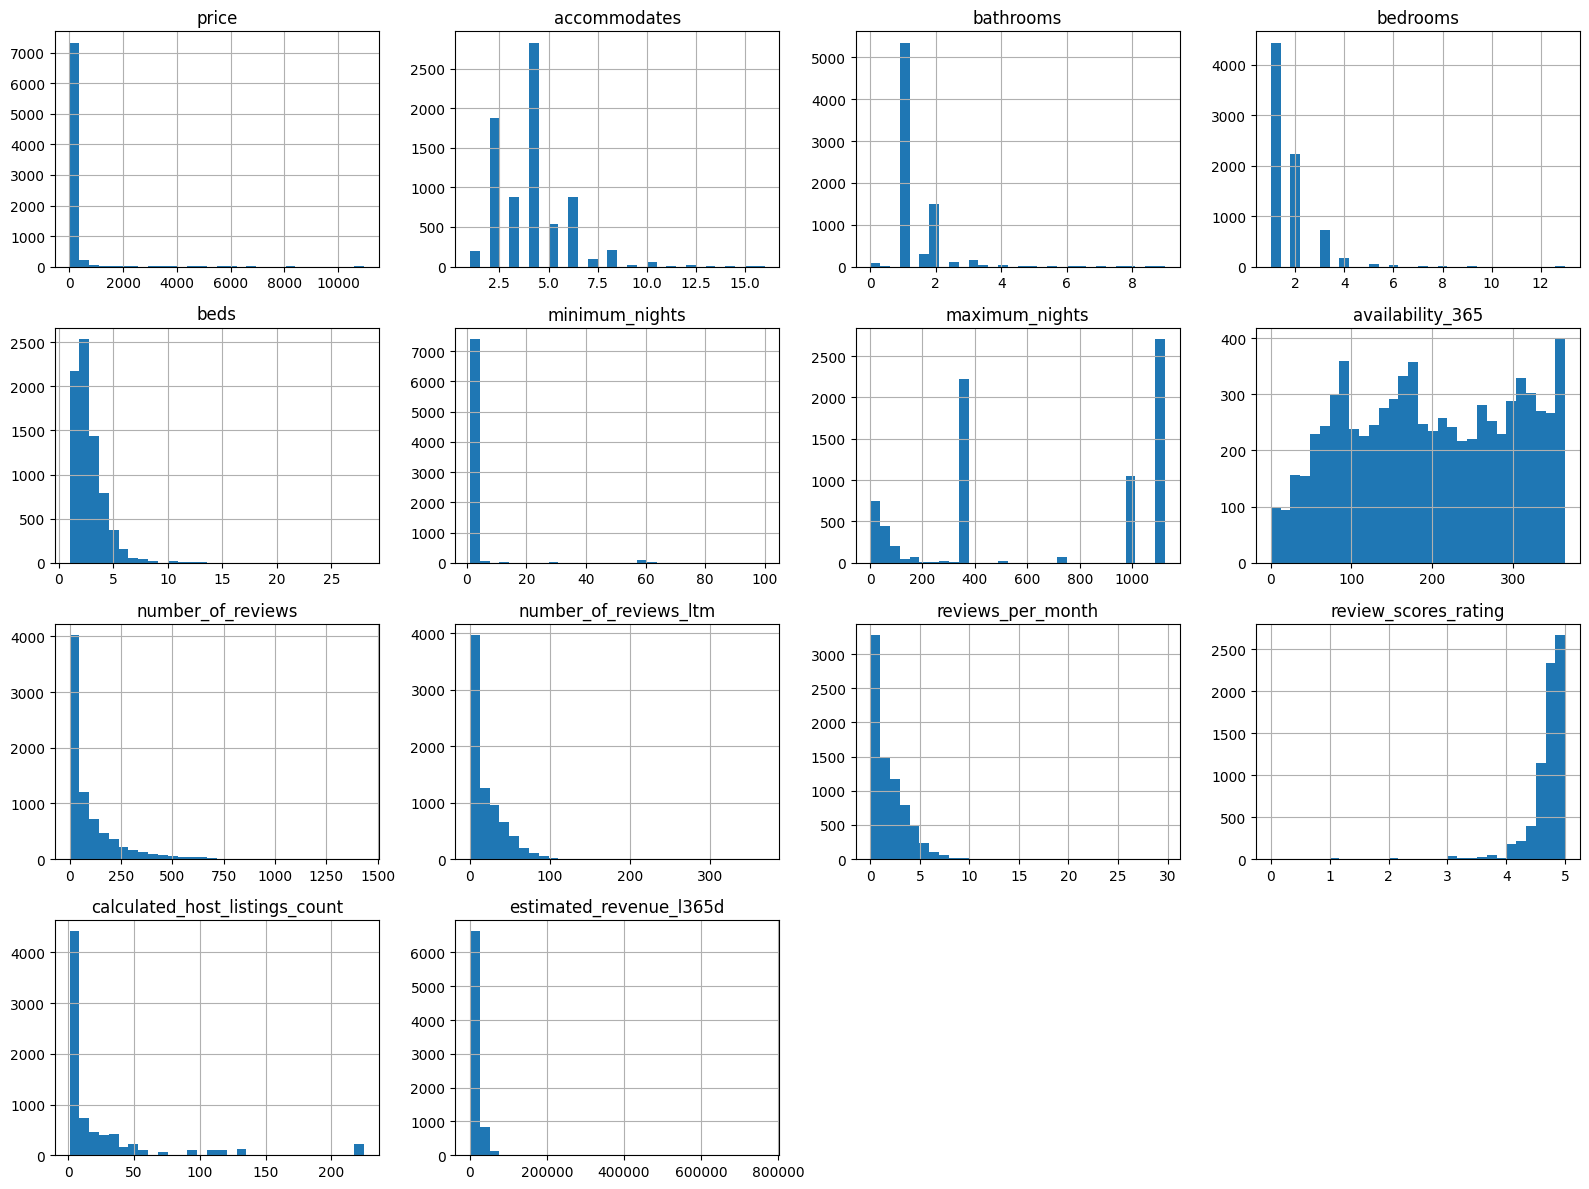

In [41]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()

## 8. Outliers

Detección y tratamiento de valores extremos que puedan distorsionar el análisis.

### 8.1 Método: rango intercuartílico (IQR)

In [42]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c, "low": low, "high": high,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
12,calculated_host_listings_count,-32.500,59.500,785,10.27
0,price,-19.750,246.250,593,7.76
8,number_of_reviews,-172.000,308.000,579,7.58
2,bathrooms,0.250,2.250,469,6.14
11,review_scores_rating,4.215,5.295,417,5.46
1,accommodates,-1.000,7.000,348,4.55
5,minimum_nights,-0.500,3.500,276,3.61
13,estimated_revenue_l365d,-23115.000,42429.000,265,3.47
3,bedrooms,-0.500,3.500,250,3.27
9,number_of_reviews_ltm,-40.000,72.000,195,2.55


`calculated_host_listings_count` (10.3%) encabeza la lista, patrón conocido de las otras ciudades. `price` sale con un 7.8%: se investiga de cerca qué hay en esa cola alta.

### 8.2 La cola alta de `price`: a diferencia de Valencia y Málaga, sin un artefacto limpio que aislar

In [43]:
df.sort_values("price", ascending=False)[["name", "host_name", "room_type", "accommodates", "number_of_reviews", "price"]].head(15)

,name,host_name,room_type,accommodates,number_of_reviews,price
2443,"Villa Gandesa, Casa Palacio de Sevilla con pis...",Casa Palacio Gandesa,Entire home/apt,16,4,10970.00
7334,Hostly Alameda 2 dorm,Joaquín Y Natalia,Entire home/apt,4,1,8240.00
7179,Rent it if you can afford it!,Alberto,Entire home/apt,6,0,8052.00
7091,NEW! Amplio apartamento en pleno centro histórico,Nacho,Entire home/apt,5,10,6792.50
1154,Apartamento 2 Dormitorios Triana,Sol,Entire home/apt,6,1,5900.00
6338,Estiloso apartamento en pleno Triana,Nacho,Entire home/apt,4,50,5722.50
896,LOLA DE TRIANA Apartments - Loft E,Magno Apartments,Entire home/apt,3,19,5025.00
7159,RentalSevilla en la Plaza del Salvador,Esther,Entire home/apt,6,20,5000.00
4928,Oasis de Triana,Nacho,Entire home/apt,2,44,4899.50
2847,AIRCON & TERRACE IN TRIANA,Alberto,Entire home/apt,8,9,4562.00


No hay aquí un salto brusco ni un grupo de precios idénticos repetidos por un mismo host (como los 19 bungalows de "Camping Valencia" o los dos precios aislados de Málaga): la cola alta de Sevilla baja de forma continua, desde 10970€ ("Villa Gandesa, Casa Palacio de Sevilla con piscina", un palacio real de 16 plazas) hasta los ~1700€, sin ningún hueco que marque una frontera clara entre "mercado real" y "artefacto". Sí hay indicios sueltos de precio disuasorio — "Rent it if you can afford it!" (8052€, 0 reseñas, el propio nombre del anuncio ya lo delata) o "Hostly Alameda 2 dorm" (8240€, 1 reseña) — pero se mezclan sin frontera con anuncios de lujo genuinos y no forman un cluster de valores repetidos que se pueda aislar y descartar con criterio objetivo.

In [44]:
import json

row = df.loc[df["name"] == "Rent it if you can afford it!"].iloc[0]
quote = json.loads(row["price_quote_raw"])["quote"]
print("fecha consultada:", quote["requested_checkin_date"], "->", quote["requested_checkout_date"])
print("price_per_night:", quote["price_per_night"])
print("disponibilidad anual:", row["availability_365"], "/ 365")

fecha consultada: 2026-07-12 -> 2026-07-13
price_per_night: 8052
disponibilidad anual: 336 / 365


El precio es internamente consistente (`price_per_night` coincide con `price`), no es un error de parseo — es, con toda probabilidad, un precio disuasorio deliberado (365 días marcados como disponibles a un precio que nadie va a pagar). Pero al no formar un cluster identificable de valores repetidos, y al no poder distinguirse con un criterio objetivo de las villas/palacios genuinamente caros del resto de la cola, **se decide no descartar ninguna fila por este concepto**: es la primera de las cinco ciudades donde la limpieza de `price` no elimina ningún outlier de la cola alta.

### 8.3 Caso concreto: un error de captura en `bedrooms`/`beds`

Al igual que en Valencia, conviene revisar el tamaño por separado del precio. Se busca el patrón ya conocido: `bedrooms` y `beds` idénticos y anormalmente altos para el `accommodates` del anuncio (la huella típica de un error de captura, estadísticas de todo el edificio copiadas en una sola fila).

In [45]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "bathrooms", "price", "number_of_reviews"]
error_mask = (df["bedrooms"] >= 8) & (df["bedrooms"] == df["beds"]) & (df["accommodates"] < df["bedrooms"])
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price,number_of_reviews
7510,Hostal Boutique en Barrio de Santa Cruz,Private room,2,13.0,13.0,1.0,44.0,92


"Hostal Boutique en Barrio de Santa Cruz": `Private room` para 2 personas con `bedrooms = beds = 13`. Los dos valores idénticos y muy por encima de lo que cabe en una habitación privada para 2 personas confirman el error (parecen las cifras de todo el hostal, no de la habitación reservable) — `bathrooms = 1` sí es coherente con una habitación individual, así que solo se corrige `bedrooms`/`beds`. Se corrige igual que un nulo: se reimputa con la misma regla ya usada en la sección 4 (mediana por `room_type`).

In [46]:
for c in ["bedrooms", "beds"]:
    df.loc[error_mask, c] = df.groupby("room_type")[c].transform("median")[error_mask]
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price,number_of_reviews
7510,Hostal Boutique en Barrio de Santa Cruz,Private room,2,1.0,1.0,1.0,44.0,92


### 8.4 Visualización

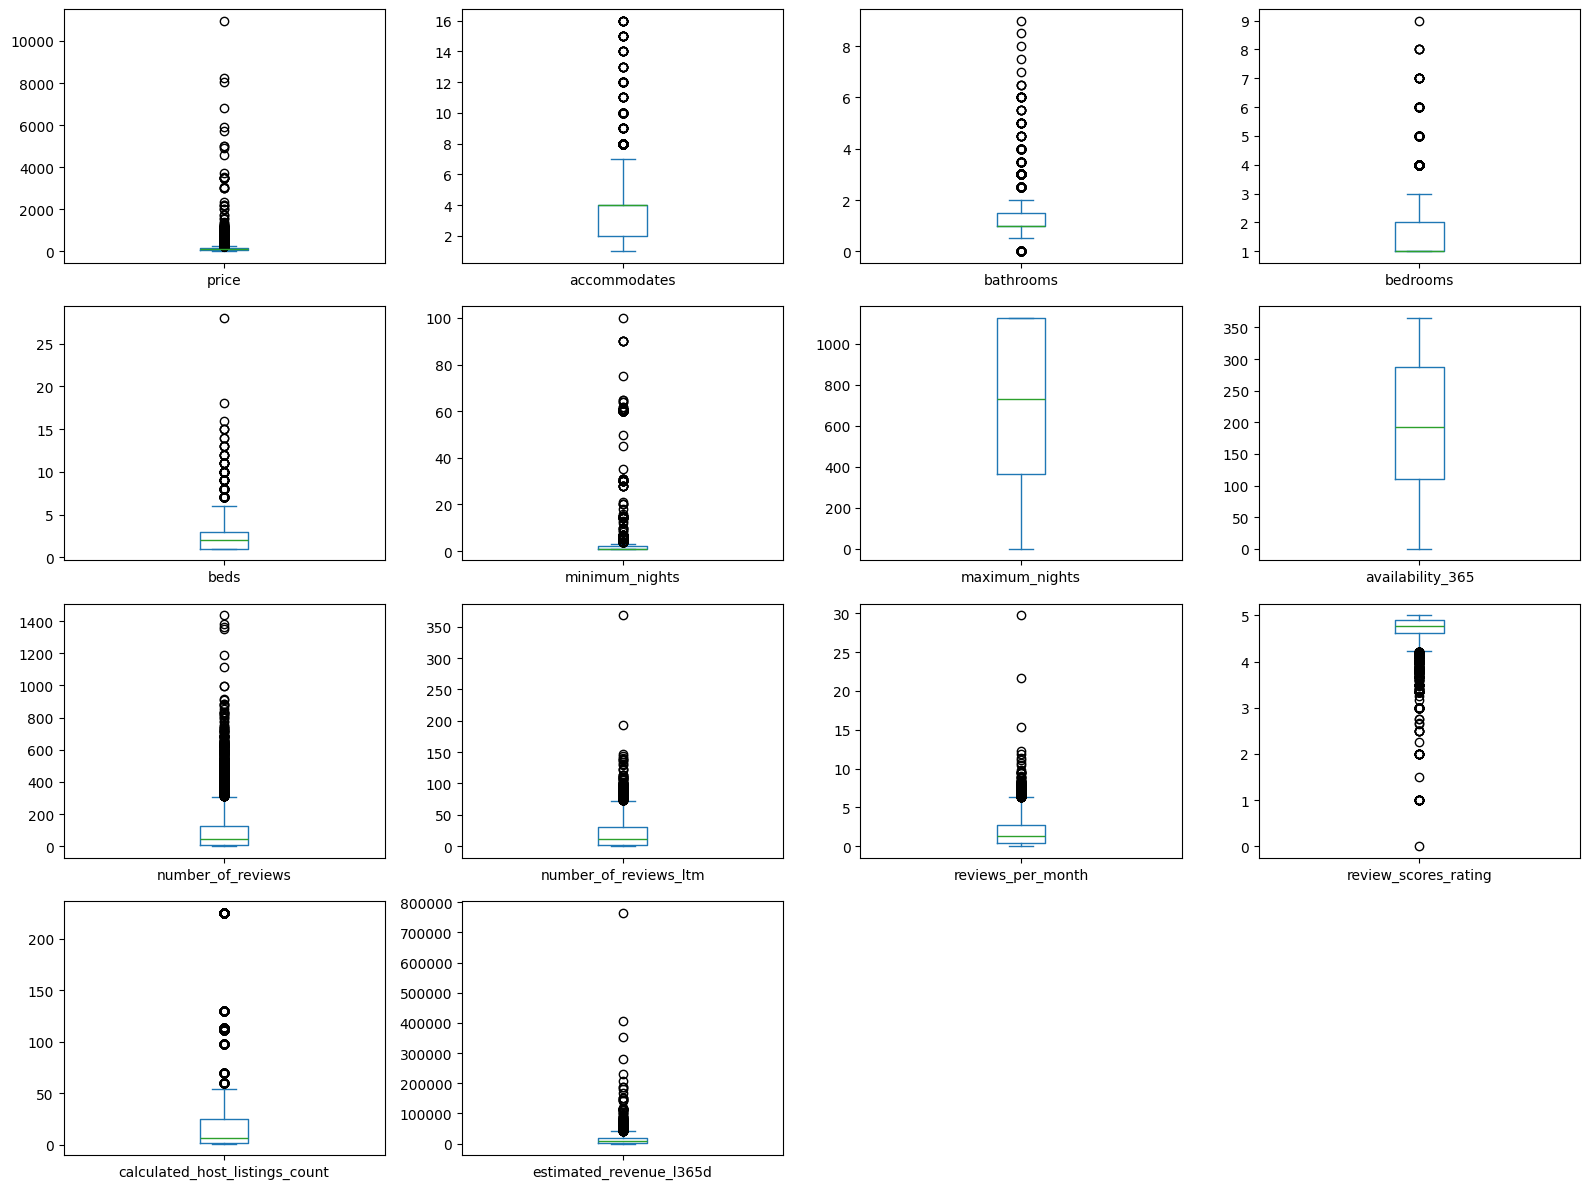

In [47]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 12))
plt.tight_layout()

### 8.5 Efecto de la corrección de tamaño: mínimo, como cabía esperar

A diferencia de Valencia y Málaga (donde descartar 2-20 filas de precio-artefacto disparaba la correlación de tamaño con `price`), aquí solo se ha corregido **una fila** de `bedrooms`/`beds`, así que no debería moverse casi nada. Se comprueba.

In [48]:
size_vars = ["accommodates", "bedrooms", "bathrooms", "beds"]
for c in size_vars:
    print(f"{c}: pearson={df['price'].corr(df[c]):.3f}  spearman={df['price'].corr(df[c], method='spearman'):.3f}")

accommodates: pearson=0.218  spearman=0.495
bedrooms: pearson=0.213  spearman=0.476
bathrooms: pearson=0.202  spearman=0.386
beds: pearson=0.161  spearman=0.435


Efectivamente, apenas cambia (`bedrooms` pasa de 0.2102 a 0.2132 en Pearson, `beds` de 0.1607 a 0.1615): una sola fila corregida no puede mover una correlación calculada sobre más de 7600 filas. Esto confirma, por el lado contrario, la conclusión de la sección 8.2: en Sevilla no hay un puñado de filas concretas distorsionando la relación tamaño-precio como en las otras ciudades — las correlaciones de tamaño son moderadas (Pearson 0.16-0.22, Spearman 0.39-0.50) porque el mercado real es así de ruidoso, no por un artefacto oculto.

### 8.6 Conclusión y tratamiento

Con la única corrección aplicada (1 fila de tamaño-artefacto reimputada en la sección 8.3), **no se recorta nada más por IQR**: el resto de "outliers" (`calculated_host_listings_count`, la cola alta de `price` de la sección 8.2 —incluida la probable pricing disuasoria que no se puede aislar con criterio objetivo—, las notas bajas de `review_scores_rating`) son variabilidad real del mercado o señales ambiguas, no errores claros. Las transformaciones para modelar (logs, etc.) se dejan para feature engineering.

## 9. Agrupaciones

Análisis bivariante: relación de `price` con otras variables categóricas.

#### `neighbourhood_group_cleansed` / `room_type` (repaso rápido)

In [49]:
print(df.groupby("neighbourhood_group_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False))
print()
print(df.groupby("room_type")["price"].agg(["count", "mean", "median"]))

                              count        mean   median
neighbourhood_group_cleansed                            
Sur                             124  174.461452  107.730
Triana                          873  166.226942  100.000
Los Remedios                    158  156.455570  106.935
Casco Antiguo                  5325  151.886086  111.000
Nervión                         448  147.065335  109.100
Macarena - Norte                 54  129.301667   71.965
San Pablo - Santa Justa         163  124.637117  103.280
Este - Alcosa - Torreblanca      68  113.443824   97.335
Palmera - Bellavista             94  108.431383   92.750
Cerro - Amate                    88  104.145341   66.095
Macarena                        245   98.425347   82.000

                 count        mean  median
room_type                                 
Entire home/apt   6665  157.966398   112.0
Hotel room          14  174.112143   121.9
Private room       937   94.556307    63.0
Shared room         24   31.208333    25.5


`Sur` encabeza por media (174.5€) y también por mediana (107.7€), por delante de `Triana` y `Los Remedios`. `Casco Antiguo`, con el 69.7% del dataset, se queda en mitad de la tabla (111€ de mediana) — igual que `Centro` en Málaga, no es el distrito más caro, solo el más numeroso. `Entire home/apt` (mediana 112€) muy por encima de `Private room` (63€) y `Shared room` (25.5€).

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

In [50]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
1.0,4439,92.00
2.0,2236,125.50
3.0,716,162.00
4.0,163,257.00
5.0,45,424.50
6.0,26,480.75
7.0,10,595.68
8.0,4,536.75
9.0,1,1416.40


Relación creciente y bastante monótona hasta 7 dormitorios: 1 → 92€, 2 → 125.5€, 3 → 162€, 4 → 257€, 5 → 424.5€, 6 → 480.75€, 7 → 595.68€. A partir de 8 dormitorios la muestra es demasiado pequeña (4 anuncios o menos) para sacar conclusiones fiables.

<Axes: xlabel='bedrooms', ylabel='price'>

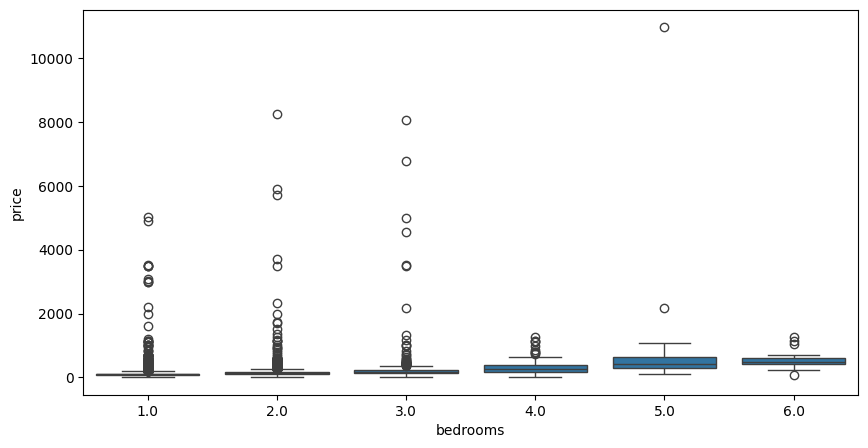

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price")

Se limita a ≤6 dormitorios (a partir de ahí la muestra es demasiado pequeña para que la caja tenga sentido). La tendencia creciente se ve con claridad.

### 9.2 Calidad: `review_scores_rating`

In [52]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(-0.0013512067100123937), np.float64(0.19539153184663655))

Pearson prácticamente nulo (-0.001), pero Spearman sube a 0.20 — más alto que en las otras cuatro ciudades. Con Pearson la nota media parece no explicar nada del precio, pero el orden de rangos sí capta algo de relación: probablemente porque los anuncios más baratos (habitaciones compartidas, hostales) también reciben notas algo más bajas en promedio, y viceversa en el segmento de pisos completos más caros.

### 9.3 `has_license`

In [53]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,430,153.786791,102.0
True,7210,149.584404,107.5


Diferencia mínima e incluso invertida en la media (153.79€ sin licencia vs. 149.58€ con ella), y muy pequeña en mediana (102€ vs. 107.5€). Se comprueba dentro de `room_type`, por si la diferencia bruta esconde algo.

In [54]:
df.groupby(["room_type", "has_license"])["price"].median()

room_type        has_license
Entire home/apt  False          117.000
                 True           112.000
Hotel room       False          710.000
                 True           109.800
Private room     False           59.670
                 True            63.995
Shared room      False           24.000
                 True            26.000
Name: price, dtype: float64

Dentro de `Entire home/apt` la diferencia es mínima (112€ con licencia vs. 117€ sin ella) y en `Private room` incluso se invierte más (64€ vs. 59.67€). A diferencia de Valencia (donde `has_license` casi duplicaba el precio), en Sevilla `has_license` **no es un factor de precio relevante**: la inmensa mayoría de anuncios (94.4%) ya tiene licencia, así que apenas queda variación real que explicar con esta variable.

### 9.4 `host_is_superhost`

In [55]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,4553,151.324494,103.5
True,3087,147.603320,113.0


Diferencia pequeña y de signo mixto (mediana 113€ con Superhost vs. 103.5€ sin él, pero media más alta sin Superhost): ser Superhost no pesa de forma consistente en el precio, igual que en las otras cuatro ciudades.

### 9.5 `property_type` (más granular que `room_type`)

In [56]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
property_type,,,
Entire home,237,327.593755,245.00
Room in hotel,88,158.603295,134.00
Entire serviced apartment,181,144.056243,123.84
Entire rental unit,5671,150.923527,111.00
Entire condo,241,123.310788,107.00
Room in aparthotel,35,165.079143,100.00
Entire loft,204,116.483775,99.25
Private room in home,223,71.622332,59.00
Private room in rental unit,389,80.417686,58.00


`Entire home` destaca con fuerza (245€ de mediana), muy por delante de `Room in hotel` (134€) y `Entire rental unit` (111€), la categoría dominante (74.2% del dataset). `Private room in hostel` es el más barato (50€).

En conjunto, esta sección apunta en una dirección algo distinta a las otras cuatro ciudades: **el tamaño sigue siendo la señal más consistente**, pero aquí ni `has_license` ni `host_is_superhost` aportan nada, y la ubicación por distrito pesa menos de lo esperado (`Casco Antiguo`, con el 69.7% del dataset, ni siquiera es el distrito más caro). Se retoma de forma cuantitativa en la sección 10.

## 10. Correlación y visualización

Análisis multivariante: correlaciones entre variables numéricas y su relación conjunta con `price`.

### 10.1 Correlación con `price`

In [57]:
corr_vars = num_vars + ["has_license", "host_is_superhost"]
df[corr_vars].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
estimated_revenue_l365d           0.266788
accommodates                      0.217821
bedrooms                          0.213156
bathrooms                         0.201982
beds                              0.161483
calculated_host_listings_count    0.032635
availability_365                  0.020209
review_scores_rating             -0.001351
has_license                      -0.003190
host_is_superhost                -0.006015
maximum_nights                   -0.019398
minimum_nights                   -0.041424
number_of_reviews                -0.069926
reviews_per_month                -0.084555
number_of_reviews_ltm            -0.085575
Name: price, dtype: float64

`estimated_revenue_l365d` (0.27) y `accommodates` (0.22) encabezan, seguidos de `bedrooms` (0.21) y `bathrooms` (0.20): magnitudes moderadas, del mismo orden que Valencia, muy por debajo de las de Barcelona. `number_of_reviews_ltm`/`reviews_per_month`/`number_of_reviews` salen en negativo, el mismo efecto ya visto en las otras ciudades (los anuncios más caros rotan menos huéspedes al año).

In [58]:
df[corr_vars].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.495075
bedrooms                          0.476452
beds                              0.435431
bathrooms                         0.386260
review_scores_rating              0.195392
estimated_revenue_l365d           0.155129
host_is_superhost                 0.093880
availability_365                  0.092531
calculated_host_listings_count    0.053286
has_license                       0.032108
maximum_nights                    0.030833
number_of_reviews                -0.103588
minimum_nights                   -0.115207
reviews_per_month                -0.135920
number_of_reviews_ltm            -0.141949
Name: price, dtype: float64

Con Spearman el panorama mejora con claridad: `accommodates` sube a **0.50**, `bedrooms` a 0.48, `beds` a 0.43 — señal mucho más fuerte y robusta a la asimetría que la de Pearson, la misma diferencia ya vista en Valencia. `review_scores_rating` también sube (0.20). Como `price` sigue teniendo una cola larga real (sección 8), Spearman es el método de referencia para juzgar la importancia relativa de las variables en Sevilla.

### 10.2 Heatmap

<Axes: >

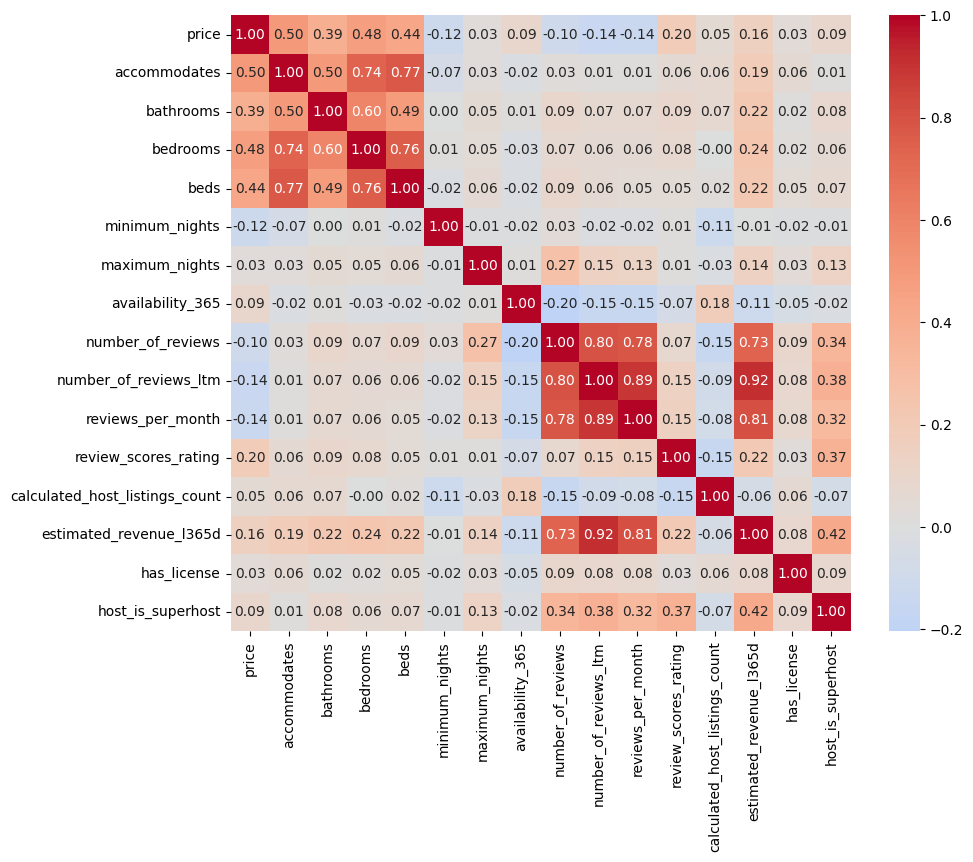

In [59]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_vars].corr(method="spearman"),
    annot=True, fmt=".2f", center=0, cmap="coolwarm",
)

`accommodates`/`bedrooms`/`beds`/`bathrooms` están muy correlacionadas entre sí (miden aspectos del mismo concepto: tamaño), algo a vigilar en un modelo lineal por multicolinealidad.

### 10.3 Pairplot

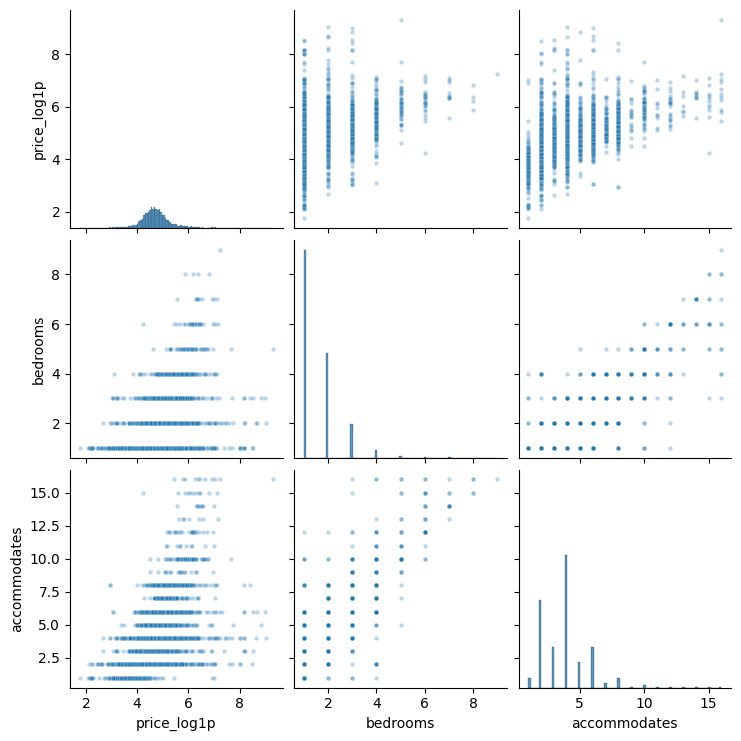

In [60]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price"] = np.log1p(pairplot_data["price"])
pairplot_data = pairplot_data.rename(columns={"price": "price_log1p"})

sns.pairplot(pairplot_data, plot_kws={"alpha": 0.3, "s": 10})

Se ve la relación creciente entre `price_log1p` y ambas variables, con dispersión notable incluso a tamaño fijo — coherente con las correlaciones moderadas de la sección 10.1: en Sevilla el tamaño explica parte del precio, pero deja bastante más varianza sin explicar que en Barcelona.

La sección 10 deja claro el orden de importancia para un futuro modelo de `price` en Sevilla: primero el **tamaño** (`accommodates`/`bedrooms`/`beds`/`bathrooms`, mejor visto con Spearman que con Pearson), después poco más — `has_license` y `host_is_superhost` no aportan aquí lo que aportaban en otras ciudades.

## 11. Análisis geográfico

Visualización espacial de los anuncios (latitud/longitud) para detectar patrones de precio o densidad por zona.

### 11.1 Rango de coordenadas

In [61]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,37.31808,-6.014320
max,37.44615,-5.903501


Rango coherente con el término municipal de Sevilla (lat ~37.32-37.45, long ~-6.01 a -5.90): sin sorpresas.

### 11.2 Distribución espacial por distrito

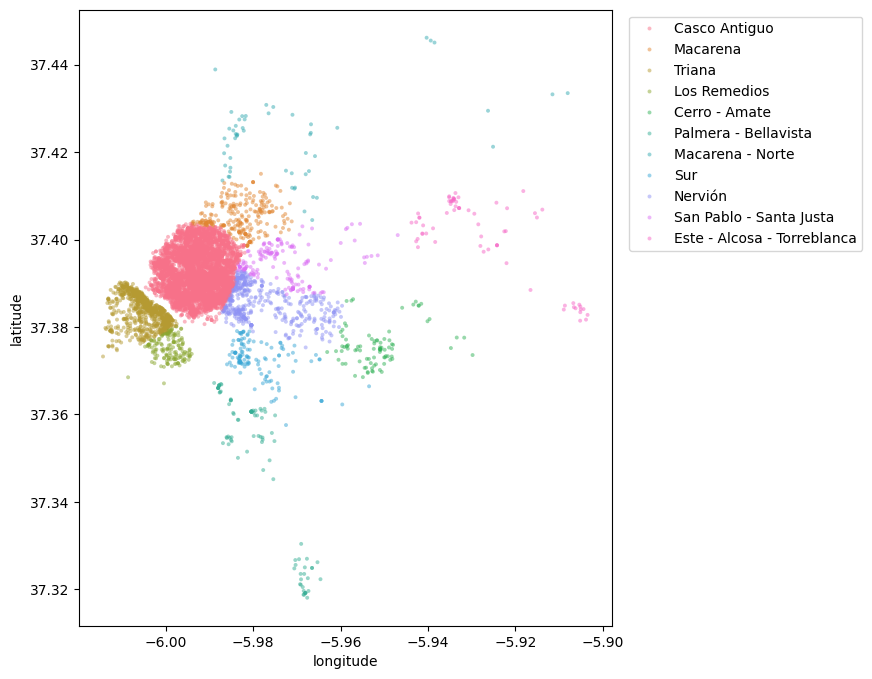

In [62]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_group_cleansed",
    s=8, alpha=0.5, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

Los 11 distritos forman regiones geográficas compactas y reconocibles, lo que confirma que `neighbourhood_group_cleansed` está bien asignado. `Casco Antiguo` (69.7% del dataset) ocupa una porción visualmente pequeña del mapa (el centro histórico, geográficamente compacto) pero concentra casi todos los puntos.

### 11.3 Precio en el mapa

Text(0, 0.5, 'latitude')

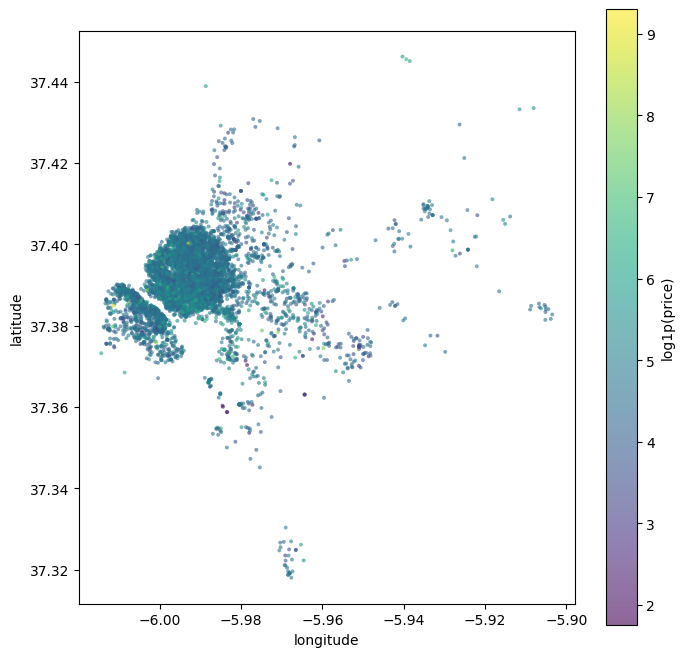

In [63]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

Sin un patrón centro-periferia tan nítido como en Barcelona/Madrid: los tonos más claros se salpican por `Triana` y el sur de la ciudad, coherente con el hallazgo de la sección 9 de que `Casco Antiguo` no es el distrito más caro pese a ser, con diferencia, el más numeroso.

### 11.4 ¿Dónde están los anuncios grandes?

In [64]:
df.loc[df["bedrooms"] >= 6, "neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Casco Antiguo    29
Sur               5
Nervión           3
Triana            2
Cerro - Amate     1
Los Remedios      1
Name: count, dtype: int64

De los 41 anuncios con 6+ dormitorios, 29 (el 70.7%) están en `Casco Antiguo` — una concentración muy parecida a la de Barcelona en `Eixample` (75%): las casas/palacios grandes del centro histórico dominan el segmento de anuncios de grupo.

### 11.5 Densidad de anuncios cercanos

`distance_to_center_km` (que se construirá en feature engineering) mide la distancia a un único punto de referencia, pero no captura si un anuncio está en un tramo con mucha oferta de Airbnb alrededor. Se cuenta, para cada anuncio, cuántos otros anuncios reales hay en un radio de 150 metros (con `BallTree` y distancia haversine).

In [65]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
n_nearby_150m = counts - 1  # excluir el propio anuncio

pd.Series(n_nearby_150m, name="n_nearby_150m").describe()

count    7640.000000
mean      105.207592
std        65.854434
min         0.000000
25%        54.750000
50%       106.000000
75%       153.000000
max       266.000000
Name: n_nearby_150m, dtype: float64

Se comprueba la correlación con `price` para valorar si merece la pena como candidata a feature.

In [66]:
pd.Series(n_nearby_150m, index=df.index, name="n_nearby_150m").corr(df["price"])

np.float64(0.027183250061343377)

Correlación casi nula (0.03), la más débil de las cinco ciudades: tiene sentido con lo ya visto en la sección 11.3 — `Casco Antiguo` (la zona con más densidad de anuncios, con diferencia) no es la más cara, así que "más anuncios cerca" no viene acompañado aquí de "zona más cara". Candidata débil para feature engineering, pero se mantiene por consistencia entre modelos.

## 12. Amenities

En la sección 6.1 `amenities` se clasificó como "cuasi-identificador de texto libre". Antes de decidir qué construir con ella, se cuantifica: qué forma tiene, cuánta variedad real hay, y si alguna señal derivada correlaciona con `price`.

### 12.1 Formato y cardinalidad

In [67]:
import ast
from collections import Counter

amenities_parsed = df["amenities"].apply(ast.literal_eval)
n_amenities = amenities_parsed.apply(len)

print("nulos:", df["amenities"].isna().sum())
n_amenities.describe()

nulos: 0


count    7640.000000
mean       32.804712
std        12.811198
min         0.000000
25%        24.000000
50%        33.000000
75%        42.000000
max        90.000000
Name: amenities, dtype: float64

Sin nulos, media de ~32.8 amenities por anuncio (mediana 33), de 0 a 90. Se comprueba cuántos valores distintos hay en total.

In [68]:
amenity_counter = Counter()
for lst in amenities_parsed:
    amenity_counter.update(lst)

n_once = sum(1 for c in amenity_counter.values() if c == 1)
print("valores distintos de amenity:", len(amenity_counter))
print(f"aparecen una sola vez: {n_once} de {len(amenity_counter)} ({n_once / len(amenity_counter):.0%})")

valores distintos de amenity: 1755
aparecen una sola vez: 981 de 1755 (56%)


1755 valores distintos, y más de la mitad (55.9%) aparece en un único anuncio: la misma cola larguísima ya vista en las otras ciudades. Un one-hot directo es inviable.

### 12.2 Top amenities y el problema de la fragmentación

In [69]:
pd.Series(dict(amenity_counter.most_common(12)), name="n_anuncios")

Wifi                     7102
Kitchen                  7013
Hair dryer               6761
Hot water                6485
Iron                     6324
Dishes and silverware    6240
Hangers                  6185
Bed linens               6032
Microwave                5991
Cooking basics           5799
Refrigerator             5763
Essentials               5617
Name: n_anuncios, dtype: int64

Las más comunes (`Wifi`, `Kitchen`, `Hair dryer`...) están en el 80-95% de los anuncios: casi universales, poco discriminantes. Un mismo concepto también se escribe de varias formas:

In [70]:
ac_variants = [k for k in amenity_counter if "air condition" in k.lower() or k.lower().startswith("ac ")]
{v: amenity_counter[v] for v in sorted(ac_variants, key=lambda k: -amenity_counter[k])}

{'Air conditioning': 5165,
 'AC - split type ductless system': 1122,
 'Central air conditioning': 1018,
 'Portable air conditioning': 45}

Cuatro variantes distintas para "tiene aire acondicionado", igual que en las otras ciudades. Hace falta agrupar por palabra clave, no tomar los valores tal cual.

### 12.3 Candidatas para feature engineering

In [71]:
def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

candidates = pd.DataFrame({
    "n_amenities": n_amenities,
    "has_ac": amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "])),
    "has_pool": amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"])),
    "has_dishwasher": amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"])),
})
candidates["price"] = df["price"]

for col in ["n_amenities", "has_ac", "has_pool", "has_dishwasher"]:
    prevalencia = candidates[col].mean() if col == "n_amenities" else candidates[col].mean() * 100
    corr = candidates[col].astype(float).corr(candidates["price"])
    label = f"media={prevalencia:.1f}" if col == "n_amenities" else f"prevalencia={prevalencia:.1f}%"
    print(f"{col:16s} {label:18s} corr con price: {corr:.3f}")

n_amenities      media=32.8         corr con price: 0.007
has_ac           prevalencia=95.7%  corr con price: 0.013
has_pool         prevalencia=10.2%  corr con price: 0.052
has_dishwasher   prevalencia=40.2%  corr con price: 0.064


Las cuatro candidatas salen **muy débiles** en Sevilla: `has_dishwasher` (0.064), `has_pool` (0.052, con solo 10.2% de prevalencia), `has_ac` (0.013, casi universal al 95.7%) y `n_amenities` (0.007) son, con claridad, las correlaciones amenities-precio más bajas de las cinco ciudades — muy lejos del 0.229 de `has_pool` en Málaga o el 0.21 de Valencia. A diferencia de esas dos ciudades costeras/de clima muy cálido, en Sevilla ni siquiera la piscina parece un factor de lujo diferenciador por sí solo: el precio aquí depende casi enteramente del tamaño (sección 10) y, en menor medida, de la ubicación exacta dentro del distrito. Aun así, se construyen las cuatro en `02_feature_engineering.ipynb` por consistencia con el resto de ciudades, sin expectativas altas de aporte.

## 13. Conclusiones

Resumen de los principales hallazgos del EDA.

### Limpieza aplicada

De las 8245 filas y 90 columnas originales quedan **7640 filas × 78 columnas**:
- 12 columnas 100% vacías eliminadas (las mismas que en las otras cuatro ciudades).
- `bathrooms` recuperado desde `bathrooms_text` (1178 de 1178 valores, incluyendo 27 casos de "half-bath" sin dígito).
- Reviews sin datos por no tener reviews todavía: `reviews_per_month` imputado a 0, el resto se deja como `NaN`/`NaT`.
- `license` convertido en flag `has_license` (93.71% con licencia), y el texto imputado a `"Sin licencia"`.
- Filas sin `price` descartadas (601).
- Columnas de bajo volumen (host/estancia, ~0.05%) descartadas (4 filas).
- `bedrooms`/`beds` imputados con la mediana por `room_type` (mediana de `bedrooms` en `Entire home/apt` = 1, más baja que en las otras ciudades).
- `has_availability` eliminada (99.97% constante).
- Sin duplicados de fila completa ni de `id`; 85 "duplicados lógicos" (mismo edificio/aparthotel) son anuncios reales distintos.
- 1 fila con `bedrooms`/`beds` de captura errónea corregida (sección 8.3).
- **Ninguna fila descartada por precio-artefacto** (sección 8.2): a diferencia de Valencia y Málaga, la cola alta de `price` no forma un cluster aislable con criterio objetivo.

### Variables nuevas

- `has_license`: flag booleano derivado de `license`.

### El hallazgo principal: el tamaño manda, pero con más ruido que en las otras ciudades

- `accommodates` (Spearman 0.50), `bedrooms` (0.48) y `beds` (0.43) son las variables más correlacionadas con `price`, el mismo patrón de las otras cuatro ciudades, pero en magnitud más moderada.
- Con Pearson las correlaciones son bastante más bajas (`accommodates` 0.22 vs. 0.50 en Spearman): `price` tiene una cola larga real incluso sin artefactos que limpiar, así que Spearman es la referencia más fiable aquí.
- Relación `bedrooms` → `price` monótona hasta 7 dormitorios: 1BR ≈ 92€, 2BR ≈ 125.5€, 3BR ≈ 162€, 4BR ≈ 257€... hasta 7 dormitorios, ≈595.68€.
- A diferencia de las otras cuatro ciudades, ni `has_license` (94.4% de prevalencia, casi sin variación que explotar) ni `host_is_superhost` aportan señal de precio consistente, y las amenities candidatas (`has_pool`, `has_ac`, `has_dishwasher`) salen con las correlaciones más débiles de las cinco ciudades.
- `Casco Antiguo` concentra el 69.7% del dataset pero no es el distrito más caro (`Sur` lo es, por mediana); los anuncios grandes (6+ dormitorios) sí se concentran ahí con fuerza (70.7%).

### Sin artefacto de precio limpio: una diferencia real con Valencia y Málaga

- La cola alta de `price` no tiene el hueco brusco ni el cluster de valores idénticos ya visto en las otras dos ciudades: baja de forma continua desde el palacio genuino más caro (10970€) hasta indicios sueltos de precio disuasorio ("Rent it if you can afford it!", 8052€, 0 reseñas) sin frontera objetiva entre ambos.
- Corregir la única fila de tamaño-artefacto detectada (sección 8.3) apenas mueve las correlaciones (`bedrooms` 0.2102→0.2132), confirmando que el ruido en la relación tamaño-precio de Sevilla es estructural, no un artefacto oculto por limpiar.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `accommodates`/`bedrooms`/`beds`/`bathrooms` correlacionadas entre sí: vigilar multicolinealidad en un modelo lineal.
- `property_type` (42 categorías) necesitará agrupar las categorías raras.
- Las familias redundantes de `minimum_nights`/`maximum_nights` y `availability` no se han simplificado, solo diagnosticado.
- `price_quote_*` sigue sin decisión; ya se usó puntualmente en la sección 8 para diagnosticar posibles precios disuasorios, pero su uso como feature está por evaluar.
- Candidatas a log-transform: `price` (asimetría todavía alta) y las variables de reviews.
- Las amenities candidatas (`has_pool`, `has_ac`, `has_dishwasher`) se construyen por consistencia, pero con expectativas de aporte más bajas que en las otras ciudades.

## 14. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/sevilla/` para su uso en los siguientes notebooks (feature engineering).

In [72]:
df.to_csv(f"{PROJECT_DIR}/data/processed/sevilla/listings_full_clean.csv", index=False)